In [1]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")


/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.12) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


In [2]:
def plot_correlation(trace):
    fig, ax = plt.subplots(dpi=100)
    sns.heatmap(np.corrcoef(trace["neuron"].T), ax=ax, cmap="seismic")
    # make it a square plot
    ax.set_aspect("equal")
    # reduce the tick size
    ax.tick_params(axis='both', which='major', labelsize=9)

In [3]:
def vonmises_pdf(x, mu, kappa):
    return np.exp(kappa * np.cos(x - mu)) / (2 * np.pi * i0(kappa))

In [27]:
def plot_samples(trace, valid_gabors):
    # share x only for 1st row of subplots
    fig, axs = plt.subplots(nrows=2, ncols=5, dpi=300, sharex="row", sharey="row")
    for idx, ax in enumerate(axs[0]):
        response = trace["neuron"][:, idx]
        response_mean = np.mean(trace['neuron'][:, idx].ravel())
        sns.histplot(response.ravel(), color="green", stat="probability", element="step", ax=ax)
        ax.text(0.05, 0.95, idx+1, fontsize=6, transform=ax.transAxes)
        ax.text(0.7, 0.95, f"{response_mean:.2f}", fontsize=6, transform=ax.transAxes)
        ax.tick_params(axis='both', which='major', labelsize=5)
        # reduce the font size of the x and y labels
        ax.xaxis.label.set_size(5)
        ax.yaxis.label.set_size(5)
        # set a title for the subplot (the neuron number)
        ax.set_title(f"Neuron {idx+1}", fontsize=6)
    for idx, ax in enumerate(axs[1]):
        ax.imshow(valid_gabors[idx], cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")

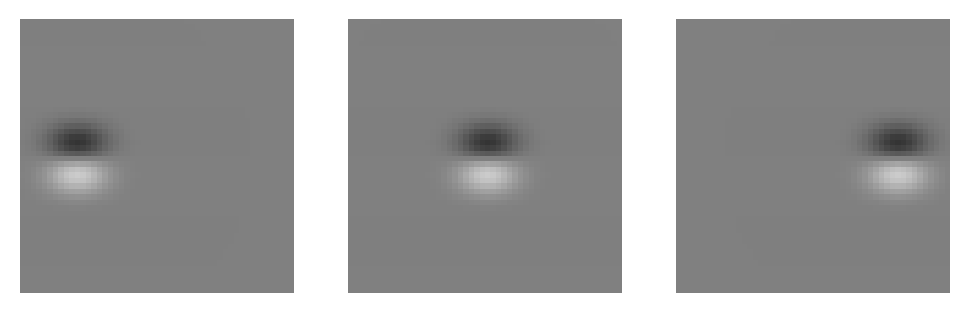

In [5]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [15],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : gabor_locations,
    "orientations"        : [np.pi/2],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)
fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = gabor_set.images()[idx]
    ax.imshow(gabor, cmap='gray', vmin=-1, vmax=1)
    ax.axis("off")

(-0.5, 49.5, 49.5, -0.5)

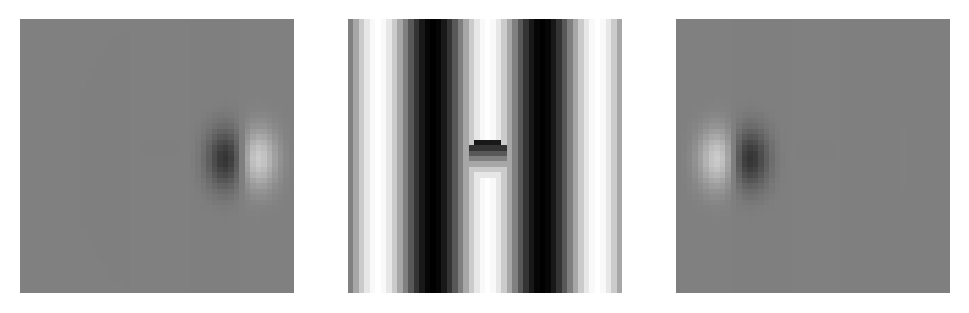

In [6]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_cut = CenterSurround(**center_surround_params)

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask_right = np.exp(-np.sum((XX - np.array([40, 25]))**2, axis=-1) / (15/4)**2 / 2)
gauss_mask_left = np.exp(-np.sum((XX - np.array([10, 25]))**2, axis=-1) / (15/4)**2 / 2)

fig, axs = plt.subplots(nrows=1, ncols=3, dpi=200)
axs[0].imshow(center_cut.images()[0]*gauss_mask_right, cmap="gray", vmin=-1, vmax=1)
axs[0].axis("off")
axs[1].imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
axs[1].axis("off")
axs[2].imshow(center_cut.images()[0]*gauss_mask_left, cmap="gray", vmin=-1, vmax=1)
axs[2].axis("off")
# plt.imshow(center_cut.images()[0] * gauss_mask, cmap="gray", vmin=-1, vmax=1)
# plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)

plt.axis("off")

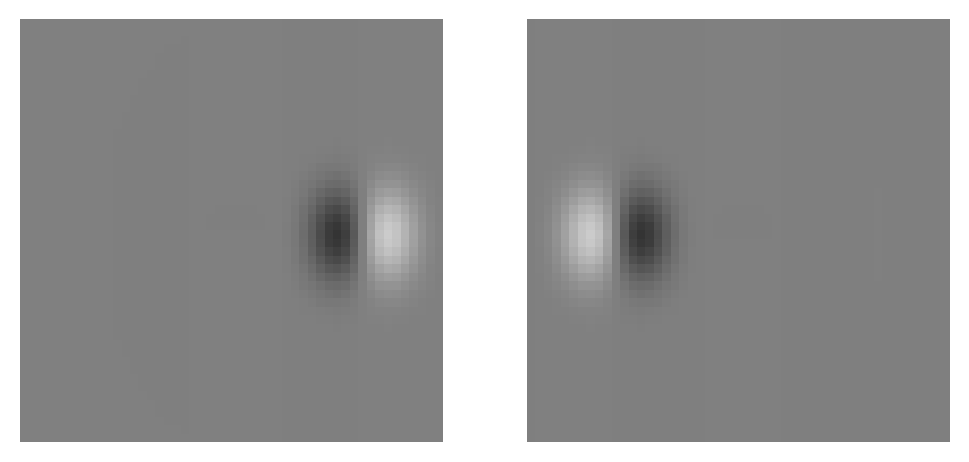

In [7]:
surround_right = center_cut.images()[0]*gauss_mask_right
surround_left = center_cut.images()[0]*gauss_mask_left
surround_filters = np.stack((surround_right, surround_left))
fig, axs = plt.subplots(ncols=2, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(surround_filters[idx], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

In [8]:
valid_gabors = np.concatenate((gabor_set.images(), surround_filters))

In [9]:
orientations = np.array([0., 0., 0., np.pi/2, np.pi/2])


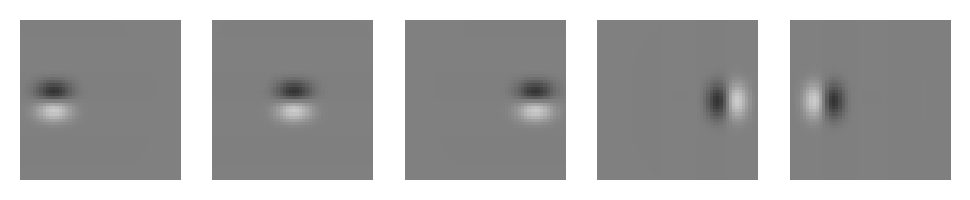

In [10]:
fig, axs = plt.subplots(nrows=1, ncols=5, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = valid_gabors[idx]
    ax.imshow(gabor, cmap='gray', vmin=-1, vmax=1)
    ax.axis("off")

In [14]:
def sample_posterior(stimulus, vonmises_kappa=1., n_samples=1000):
    vonmises_loc = 0.
    n_neurons = len(valid_gabors)
    stimulus_sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        o = pm.Uniform("orientation", lower=0, upper=np.pi)
        z = pm.Exponential(
            "neuron", 
            lam=vonmises_pdf(o - [np.pi/2, np.pi/2, np.pi/2, 0., 0.], vonmises_loc, vonmises_kappa),
            shape=n_neurons
        )
        x = pm.Normal("stimulus", mu=valid_gabors.transpose(1, 2, 0) @ z, sigma=stimulus_sigma, observed=stimulus)
        trace = pm.sample(n_samples, return_inferencedata=False)
    return trace

(-0.5, 49.5, 49.5, -0.5)

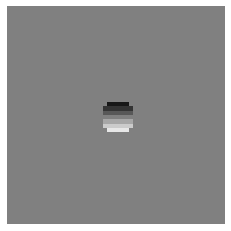

In [12]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi/2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [0],
}

center_cut = CenterSurround(**center_surround_params)

plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [15]:
center_trace = sample_posterior(center_cut.images()[0])

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [orientation, neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7191, but should be close to 0.8. Try to increase the number of tuning steps.


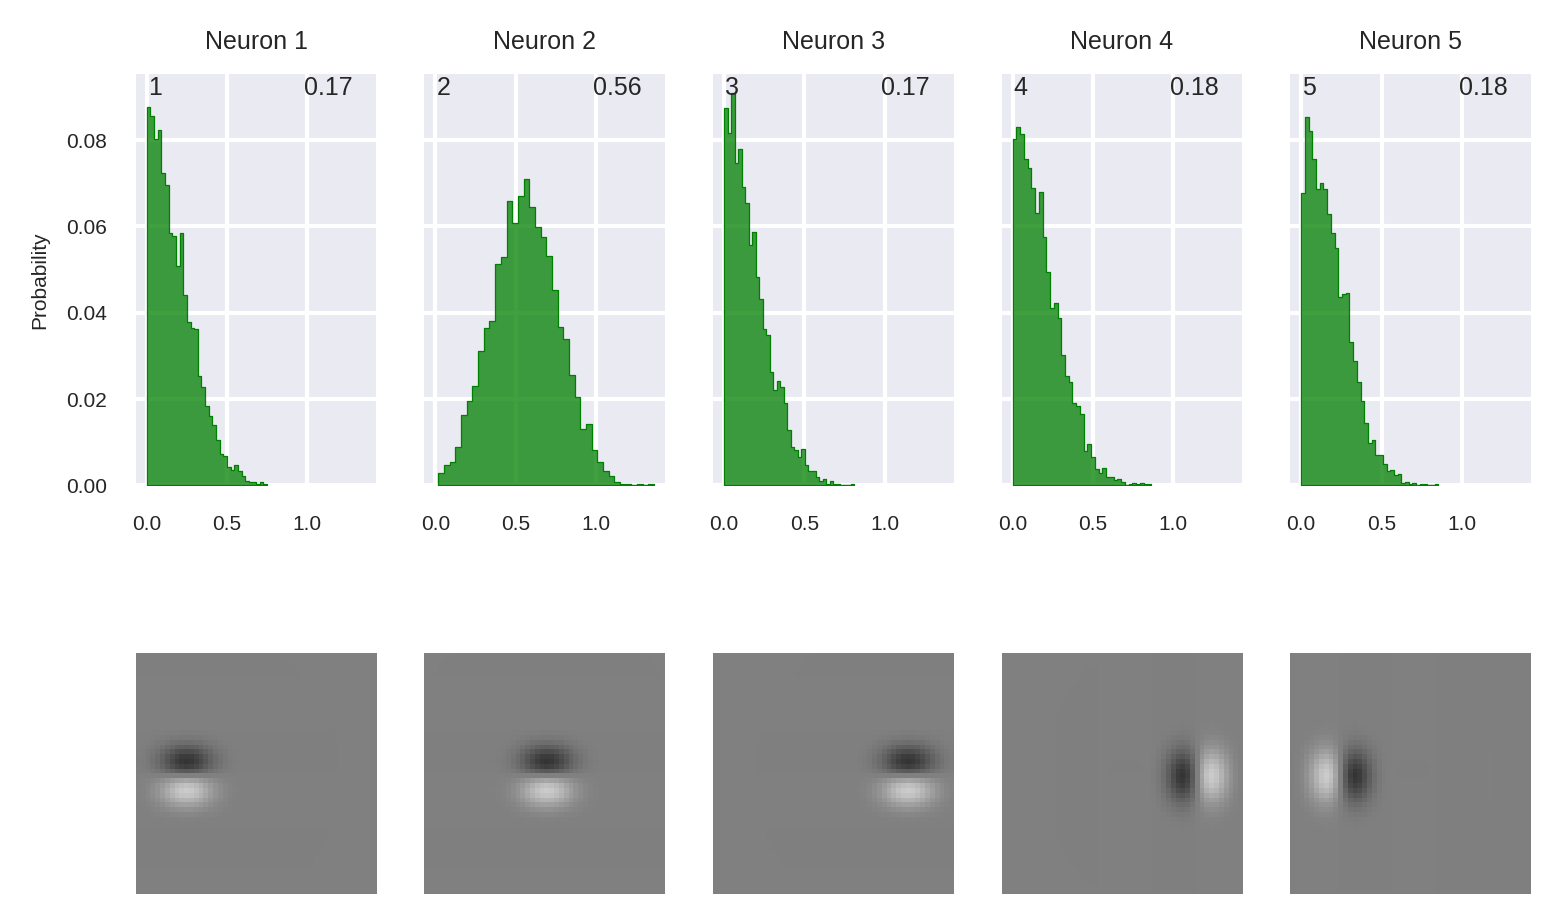

In [28]:
plot_samples(center_trace, valid_gabors)

/tmp/ipykernel_5745/3654743940.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_orientation.set_xticklabels(xticklabels)


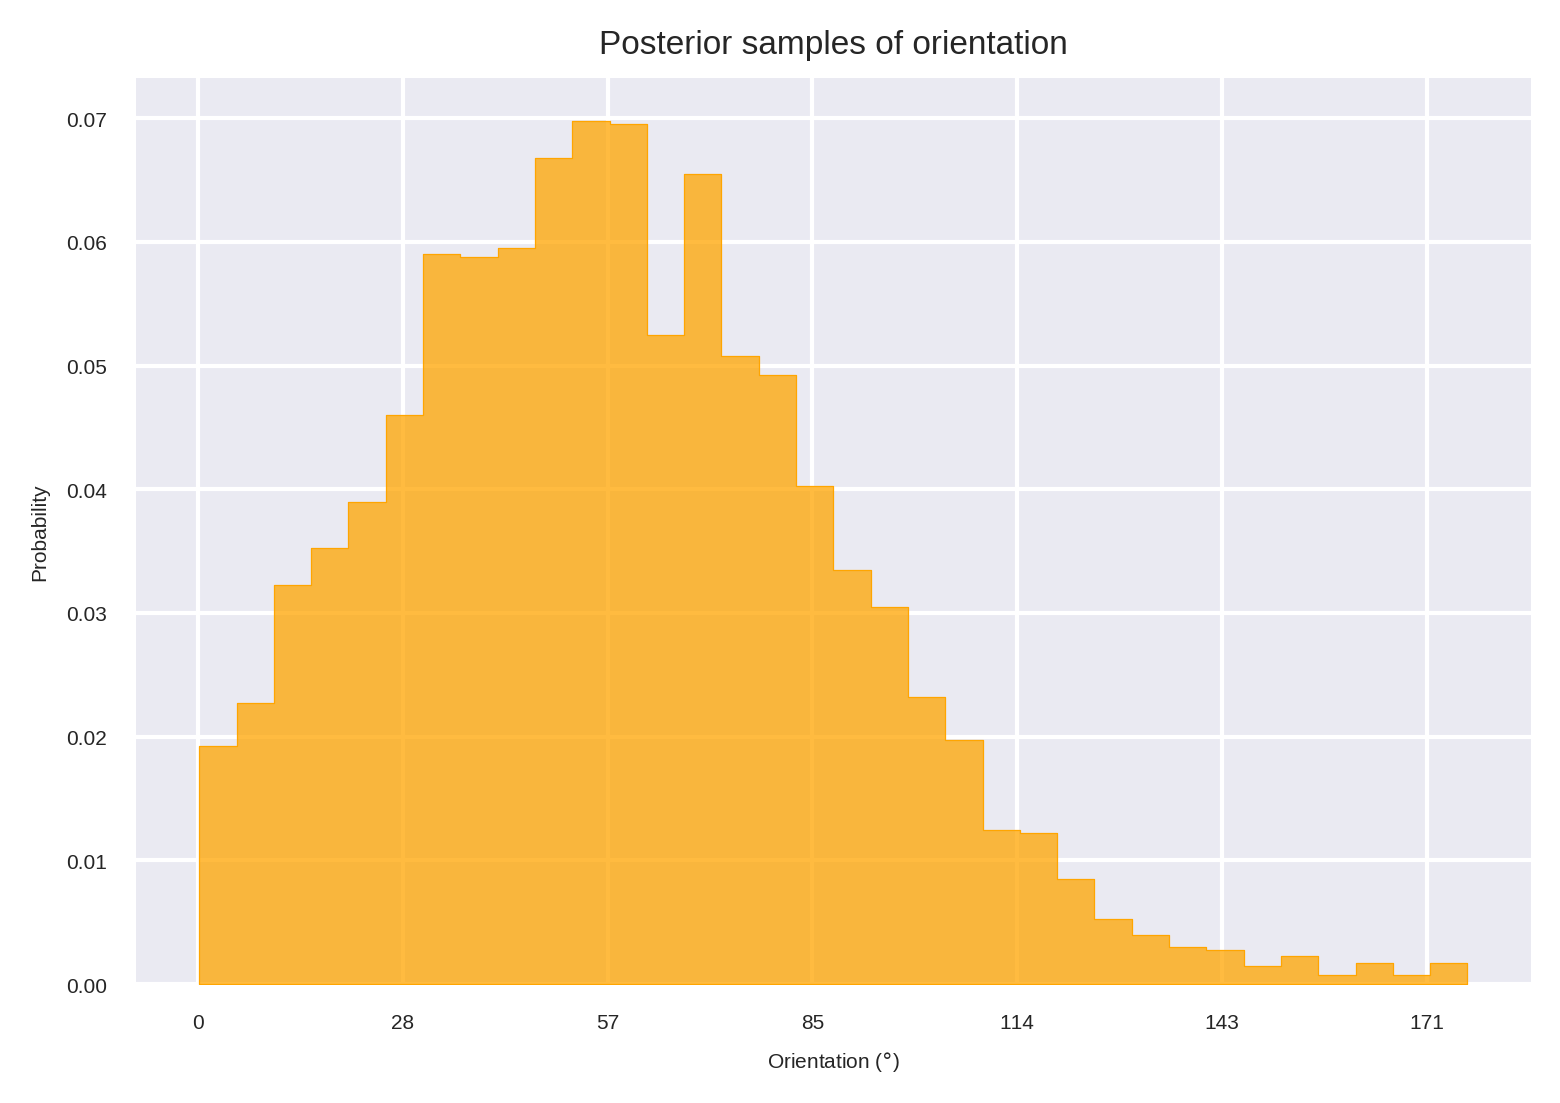

In [34]:
fig_orientation, ax_orientation = plt.subplots(dpi=300)
sns.histplot(
    center_trace["orientation"].ravel(),
    color="orange",
    stat="probability",
    element="step",
    ax=ax_orientation,
)
ax_orientation.set_title("Posterior samples of orientation", fontsize=8)
ax_orientation.set_xlabel("Orientation ($\degree$)", fontsize=6)
ax_orientation.set_ylabel("Probability", fontsize=6)
ax_orientation.tick_params(axis="both", which="major", labelsize=5)
# convert xtick labels to degrees
xticks = ax_orientation.get_xticks()
xticklabels = [f"{int(np.rad2deg(xtick))}" for xtick in xticks]
ax_orientation.set_xticklabels(xticklabels)
ax_orientation.xaxis.label.set_size(5)
ax_orientation.yaxis.label.set_size(5)


(-0.5, 49.5, 49.5, -0.5)

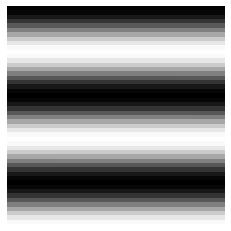

In [35]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1/20],
    "spatial_frequencies_surround": [1/20],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [np.pi/2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

congruent = CenterSurround(**center_surround_params).images()[0]
plt.imshow(congruent, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")


In [36]:
congruent_stimulus = congruent

In [37]:
congruent_trace = sample_posterior(congruent)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [orientation, neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
The acceptance probability does not match the target. It is 0.8826, but should be close to 0.8. Try to increase the number of tuning steps.


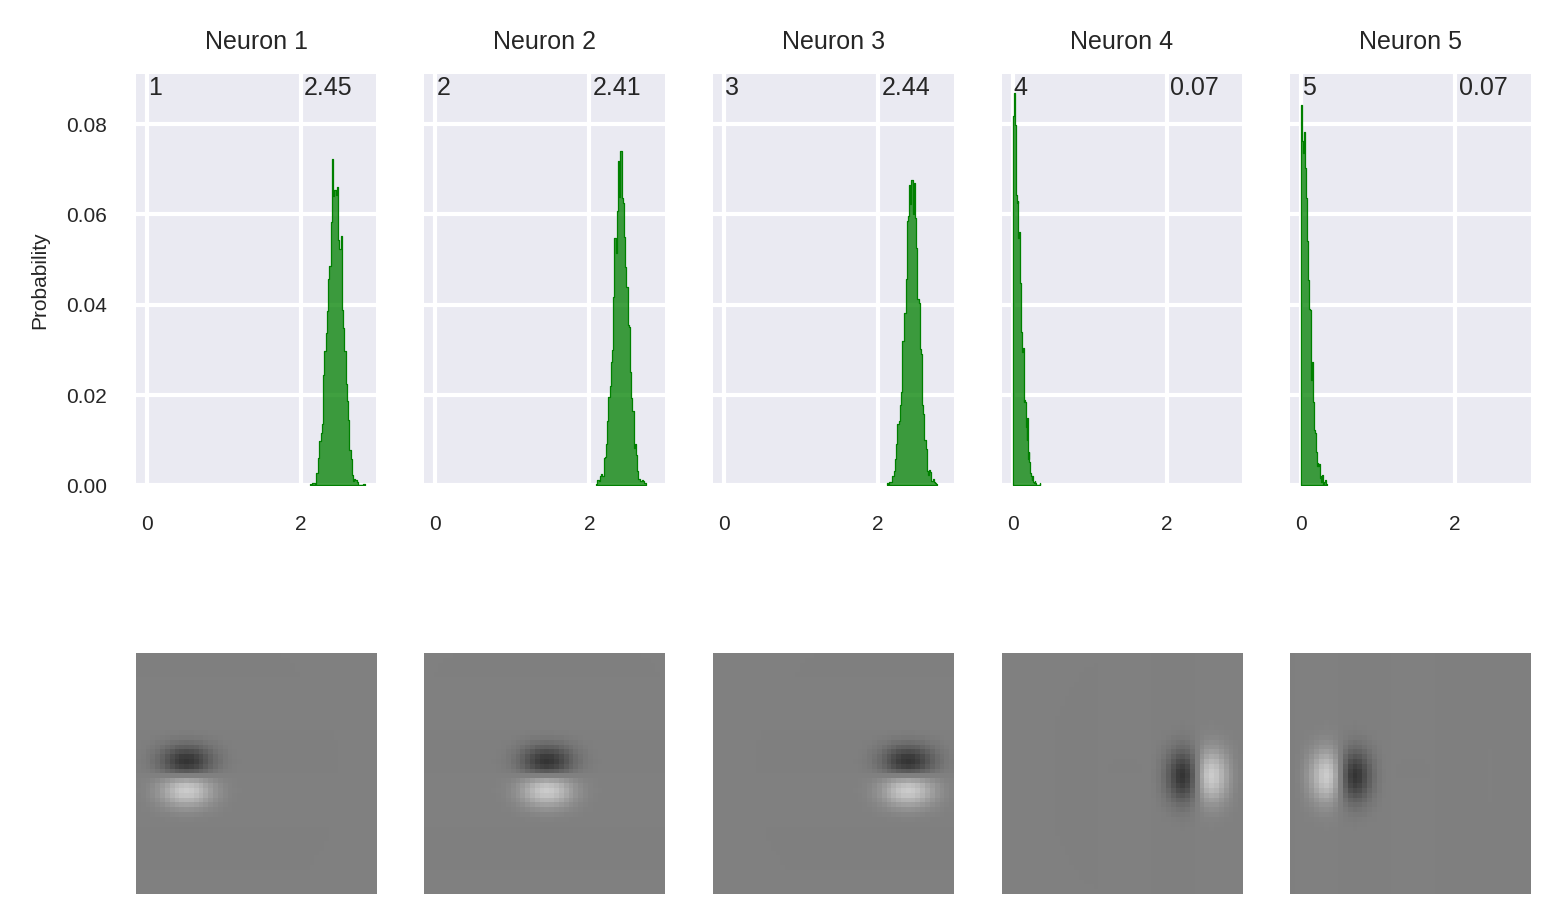

In [38]:
plot_samples(congruent_trace, valid_gabors)

(-0.5, 49.5, 49.5, -0.5)

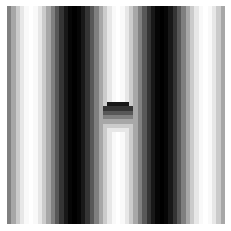

In [39]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1/20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi/2 + 2*np.pi*1/20*(25-10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi/2],
    "orientations_surround": [0.],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15/4/50],
    "sizes_surround": [15/4/50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

incongruent = CenterSurround(**center_surround_params).images()[0]
plt.imshow(incongruent, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [40]:
stimuli = np.array([center_cut_stimulus, congruent_stimulus, incongruent])

NameError: name 'center_cut_stimulus' is not defined

In [25]:
np.save("/src/project/computed/center_cut_congruent_incongruent.npy", stimuli)

In [41]:
incongruent_trace = sample_posterior(incongruent)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [orientation, neuron]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


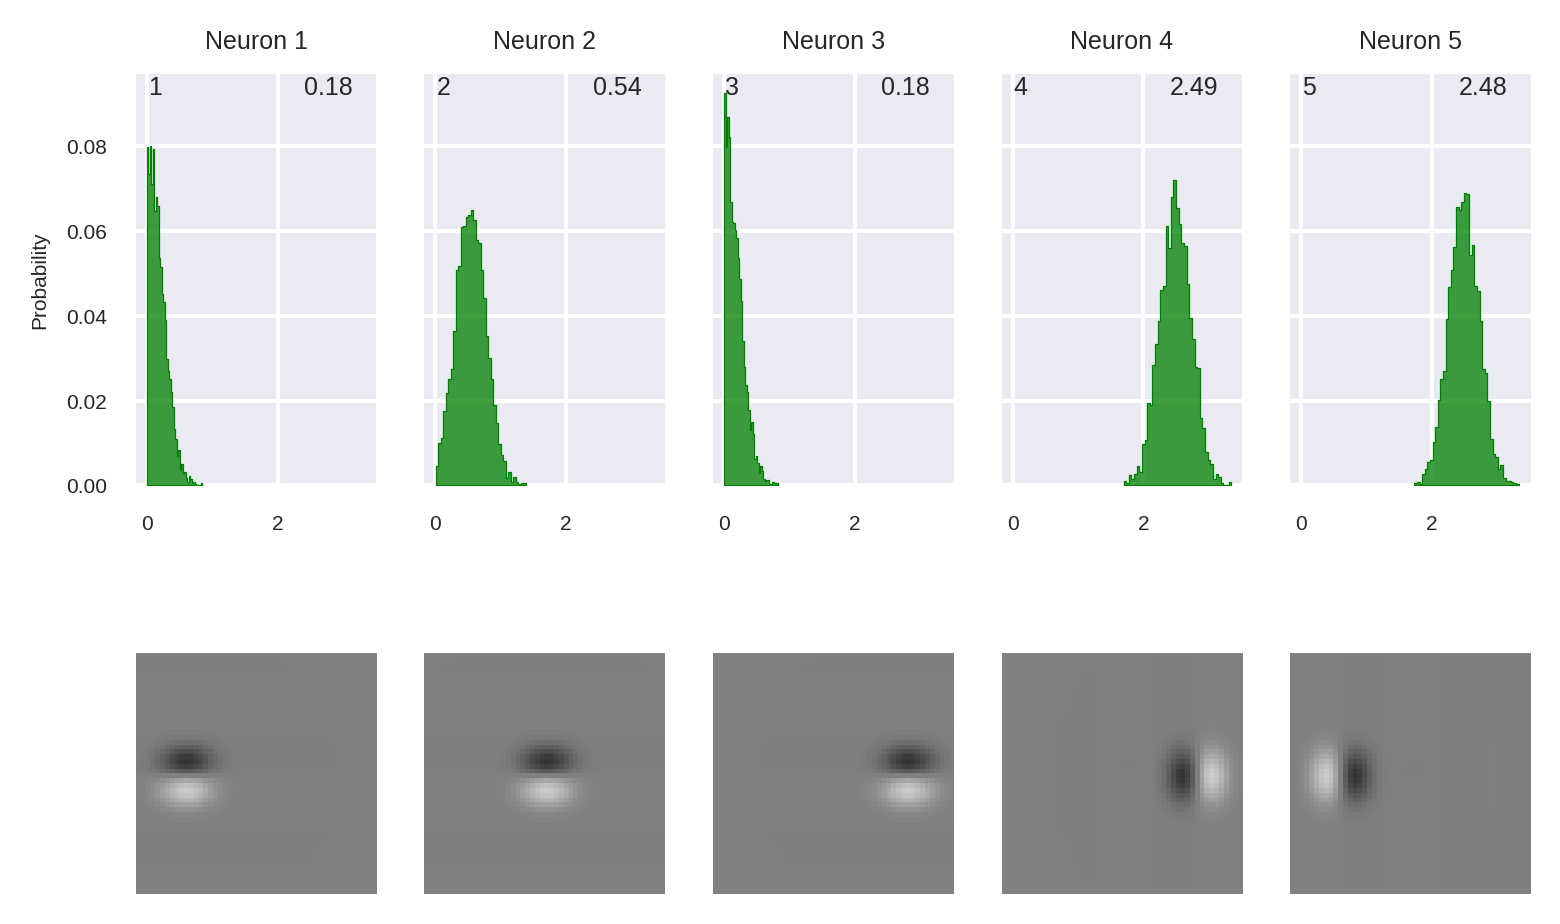

In [42]:
plot_samples(incongruent_trace, valid_gabors)

Text(0.5, 1.0, 'Posterior samples of center neuron')

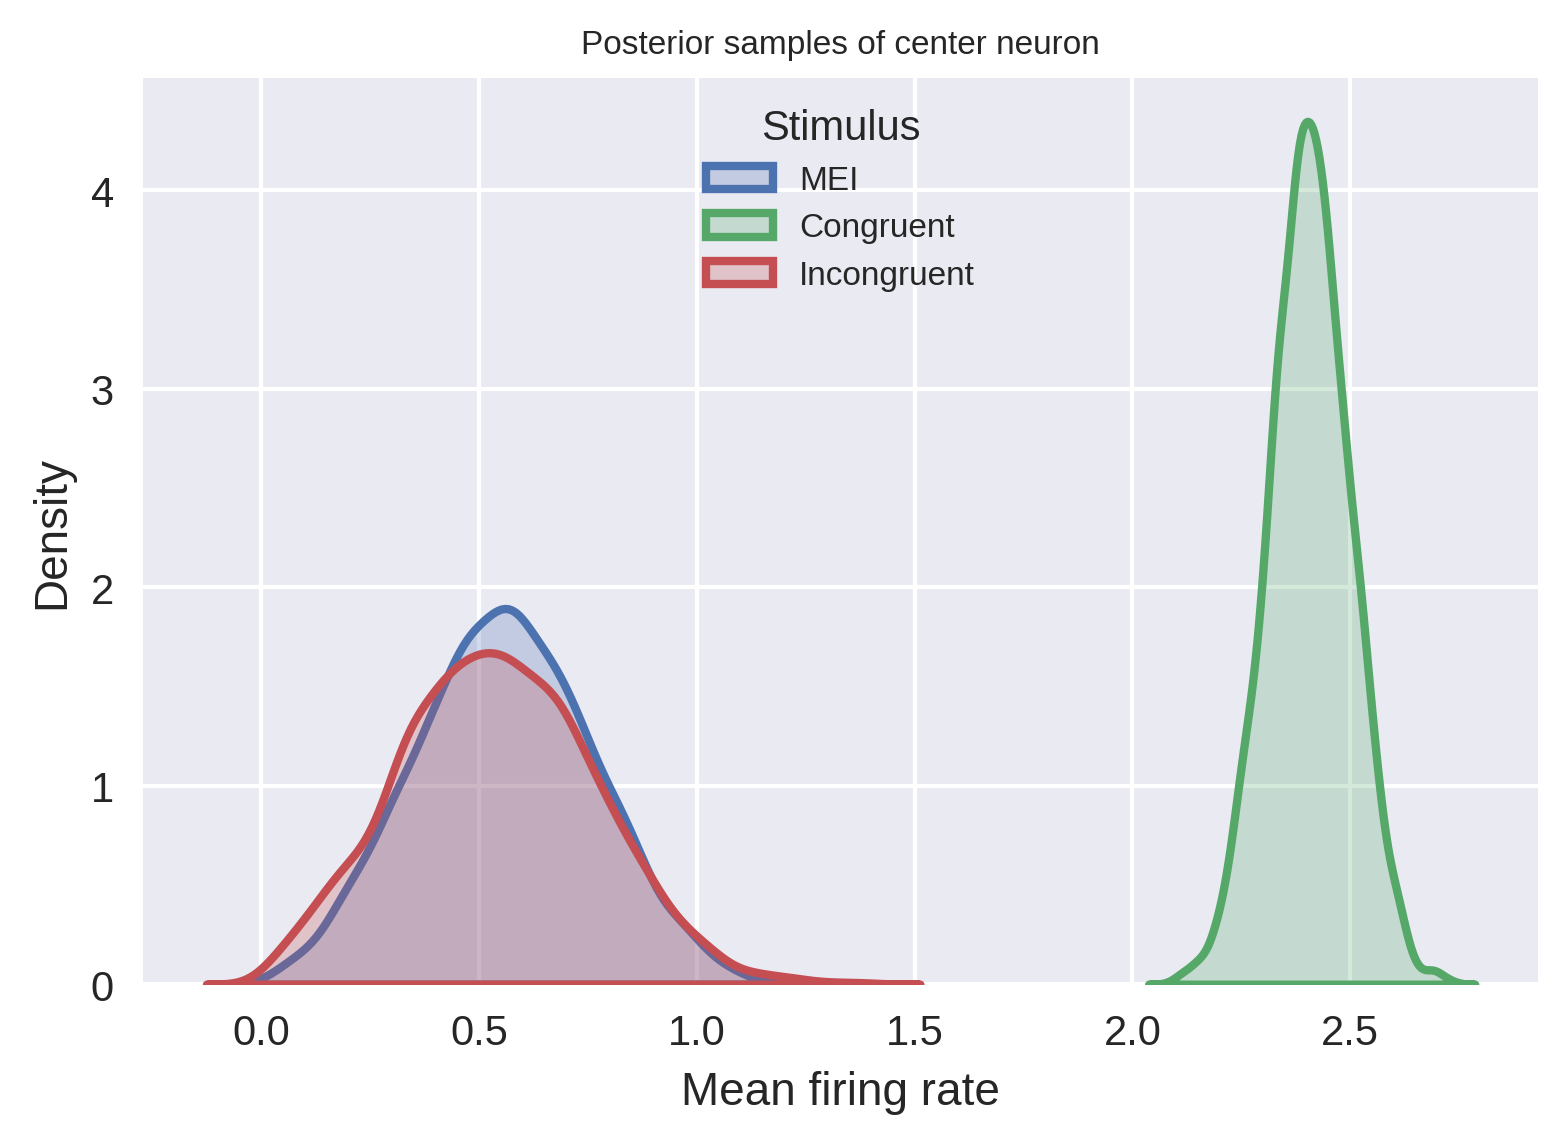

In [49]:
# plot a seaborn histogram using kdeplot for all traces with labels
# fill the kde plots with the same color
fig, ax = plt.subplots(dpi=300)
sns.kdeplot(center_trace["neuron"][:, 1].ravel(), linewidth=2, shade=True, label="MEI")
sns.kdeplot(congruent_trace["neuron"][:, 1].ravel(), linewidth=2, shade=True, label="Congruent")
sns.kdeplot(incongruent_trace["neuron"][:, 1].ravel(), linewidth=2, shade=True, label="Incongruent")
# sns.kdeplot(surround_only_trace["neuron"][:, -2].ravel(), linewidth=2, shade=True, label="Surround only")
# sns.kdeplot(surround_moat_trace["neuron"][:, -2].ravel(), linewidth=2, shade=True, label="Surround moat")
# label the x axis with "firing rate"
ax.set_xlabel("Mean firing rate")
# move the legend to the top center
ax.legend(prop={'size': 8}, title='Stimulus', title_fontsize=10, loc="upper center")
# set the title
ax.set_title("Posterior samples of center neuron", fontsize=8)